    Sprint 2

    1. Advanced EDA

Підготовка та фільтрація ознак:

На цьому етапі виконується завантаження очищеного датасету та відбір колонок для моделювання які мають задукоментований опис значення. Зі списку 115 таких ознак автоматично залишаються лише ті 102, що фізично присутні у файлі після попереднього очищення. Це гарантує відсутність помилок під час подальшої обробки даних на AWS.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

# 1. Завантажуємо датасет
path = "../data/cleaned_dataset.csv"
df = pd.read_csv(path, engine='pyarrow')

# 2. Визначаємо список ознак
target = 'target'
features_to_analyze = [
    'CALCULATION_METHOD_ID', 'calls_count_in_weekdays', 'calls_duration_in_weekdays',
    'calls_count_out_weekdays', 'calls_duration_out_weekdays', 'calls_count_in_weekends',
    'calls_duration_in_weekends', 'calls_count_out_weekends', 'calls_duration_out_weekends',
    'DATA_VOLUME_WEEKDAYS', 'DATA_VOLUME_WEEKENDS', 'LAT_HOME', 'LON_HOME',
    'Oblast_post_HOME', 'Raion_post_HOME', 'City_post_HOME', 'lat_quad_home',
    'lon_quad_home', 'LAT_WORK', 'LON_WORK', 'Oblast_post_WORK', 'Raion_post_WORK',
    'City_post_WORK', 'lat_quad_work', 'lon_quad_work', 'device_brand',
    'device_model', 'software_os_vendor', 'software_os_name', 'software_os_version',
    'device_type_rus', 'sim_count', 'AVG_ARPU', 'ROUM', 'phone_value', 'SCORING',
    'car', 'gender', 'lifetime', 'how_long_same_model', 'ecommerce_score',
    'PRIVAT', 'OSCHADBANK', 'ALFABANK', 'UKRSOTBANK', 'OTP', 'UKRGASBANK',
    'RAIFFEISEN', 'PIVDENNYI', 'IDEABANK', 'SBERBANK', 'MONOBANK',
    'PRAVEXBANK', 'UKRSIB', 'banks_sms_count', 'SHELL', 'OKKO', 'SUNOIL',
    'KLO', 'BRSM', 'AMIC', 'TNK', 'UPG', 'gas_stations_sms',
    'fb_volume', 'fb_count', 'instagram_volume', 'intagram_count',
    'viber_volume', 'viber_count', 'youtube_volume', 'youtube_count',
    'google_volume', 'google_count', 'gmail_volume', 'gmail_count',
    'skype_volume', 'skype_count', 'twitter_volume', 'twitter_count',
    'dropbox_volume', 'dropbox_count', 'uber_volume', 'uber_count',
    'steam_volume', 'steam_count', 'whatsapp_volume', 'whatsapp_count',
    'itunes_volume', 'itunes_count', 'snapchat_volume', 'snapchat_count',
    'linkedin_volume', 'linkedin_count', 'twitch_volume', 'twitch_count',
    'tumblr_volume', 'tumblr_count', 'flickr_volume', 'flickr_count',
    'badoo_volume', 'badoo_count', 'tinder_volume', 'tinder_count',
    'netflix_volume', 'netflix_count', 'applemaps_volume', 'applemaps_count',
    'msoffice365_volume', 'msoffice365_count', 'jabber_volume', 'jabber_count',
    'telegram_volume', 'telegram_count', 'user_hash'
]

# Залишаємо тільки ті колонки, які фізично є в наявному датасеті
existing_cols = [col for col in features_to_analyze if col in df.columns] + [target]
df_sub = df[existing_cols].copy()

# Виведення інформації про розмірність
print(f"Обрано ознак для аналізу: {len(df_sub.columns) - 1}")
print(f"Розмірність початкового датасету (df): {df.shape}")
print(f"Розмірність відібраного датасету (df_sub): {df_sub.shape}")

Обрано ознак для аналізу: 102
Розмірність початкового датасету (df): (22104, 1281)
Розмірність відібраного датасету (df_sub): (22104, 103)


    Оцінка значущості числових параметрів та Feature selection: 

На цьому етапі було проведено оптимізацію структури даних шляхом усунення надлишкових ознак, що дублюють одна одну. Замість окремих стовпців для кожного банку та мережі АЗС було залишено лише загальні агреговані лічильники banks_sms_count та gas_stations_sms. Це дозволило зменшити розмірність датасету та уникнути мультиколінеарності, зберігши при цьому ключову інформацію про активність абонентів.

Також було проведено розрахунок математичного зв’язку між кожною числовою ознакою та віковою категорією абонента. Використовується два методи: Mutual Information для пошуку складних нелінійних патернів та кореляція Спірмена для оцінки монотонних залежностей. Для забезпечення високої точності відбору було впроваджено метод відсікання шуму за допомогою контрольної ознаки з випадковими числами. Усі ознаки, чиї показники MI Score або кореляції виявилися нижчими за випадковий поріг (MI > 0.00000, Spearman > 0.00306), було видалено як неінформативні. Результатом є візуалізація ТОП-15 ознак-лідерів, таких як lifetime та instagram_volume, які мають найбільший вплив на прогноз віку.

Видалено 13 деталізованих ознак банків та АЗС. Залишено загальні лічильники.

Аналізуємо 76 числових ознак...
Розрахунок Mutual Information (MI)...
Розрахунок кореляції Спірмена...
Пороги шуму: MI > 0.00000, Spearman > 0.00172

Ознак після відсікання шуму: 74 з 76

Топ-15 числових ознак за MI Score (очищені):
                       MI Score  Spearman Correlation
intagram_count         0.092720              0.367490
instagram_volume       0.092203              0.372454
lifetime               0.089575              0.241580
DATA_VOLUME_WEEKDAYS   0.083179              0.364025
DATA_VOLUME_WEEKENDS   0.073434              0.344014
CALCULATION_METHOD_ID  0.070753              0.354103
fb_count               0.067711              0.337447
fb_volume              0.061663              0.336665
google_volume          0.060937              0.320413
google_count           0.060847              0.311971
youtube_volume         0.058531              0.328005
youtube_count          0.053647          

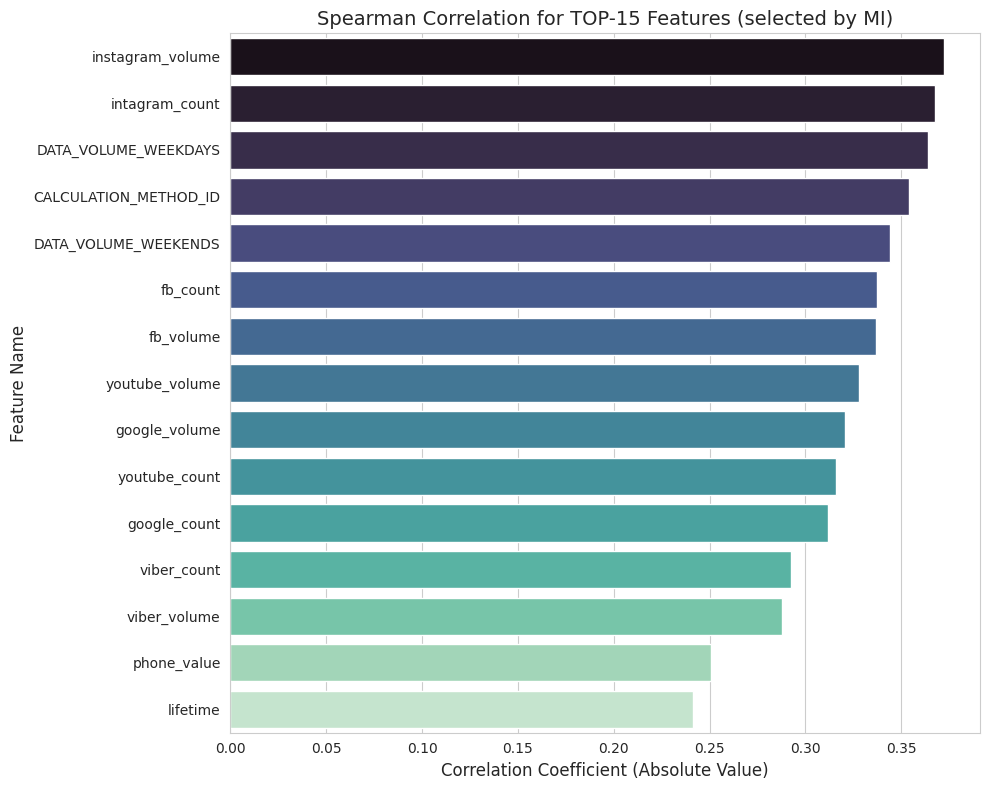

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

# 1. Feature Selection: Видалення дублюючих ознак (банки та заправки)
banks_to_drop = [
    'PRIVAT', 'OSCHADBANK', 'ALFABANK', 'UKRSOTBANK', 'OTP', 'UKRGASBANK',
    'RAIFFEISEN', 'PIVDENNYI', 'IDEABANK', 'SBERBANK', 'MONOBANK',
    'PRAVEXBANK', 'UKRSIB'
]
gas_to_drop = ['SHELL', 'OKKO', 'SUNOIL', 'KLO', 'BRSM', 'AMIC', 'TNK', 'UPG']

cols_to_drop = [col for col in banks_to_drop + gas_to_drop if col in df_sub.columns]
df_sub = df_sub.drop(columns=cols_to_drop)

print(f"Видалено {len(cols_to_drop)} деталізованих ознак банків та АЗС. Залишено загальні лічильники.\n")

# 2. Виділення числових ознак (без цільової змінної)
numeric_df = df_sub.select_dtypes(include=[np.number])
X_numeric = numeric_df.drop(columns=[target])
y = numeric_df[target]

print(f"Аналізуємо {X_numeric.shape[1]} числових ознак...")

# 3. Створення рандомної змінної для базового порогу (baseline)
np.random.seed(42)
X_numeric['random_noise'] = np.random.normal(0, 1, size=len(X_numeric))

# 4. Розрахунок Mutual Information
print("Розрахунок Mutual Information (MI)...")
mi_scores = mutual_info_classif(X_numeric, y, random_state=42)
mi_results = pd.Series(mi_scores, index=X_numeric.columns).sort_values(ascending=False)

# 5. Розрахунок кореляції Спірмена
print("Розрахунок кореляції Спірмена...")
spearman_corr = X_numeric.corrwith(y, method='spearman').abs().sort_values(ascending=False)

# 6. Отримання порогів відсікання та фільтрація результатів
mi_threshold = mi_results['random_noise']
spearman_threshold = spearman_corr['random_noise']

print(f"Пороги шуму: MI > {mi_threshold:.5f}, Spearman > {spearman_threshold:.5f}\n")

analysis_results = pd.DataFrame({
    'MI Score': mi_results,
    'Spearman Correlation': spearman_corr
})

# Видалення самої колонки шуму з результатів
analysis_results = analysis_results.drop('random_noise')

# Фільтрація: залишаємо тільки ті ознаки, які кращі за рандомні числа за обома метриками
filtered_results = analysis_results[
    (analysis_results['MI Score'] > mi_threshold) & 
    (analysis_results['Spearman Correlation'] > spearman_threshold)
].sort_values(by='MI Score', ascending=False)

print(f"Ознак після відсікання шуму: {len(filtered_results)} з {len(analysis_results)}")

# 7. Вивід результатів у консоль
top_15 = filtered_results.head(15)
print("\nТоп-15 числових ознак за MI Score (очищені):")
print(top_15)

# 8. Візуалізація ТОП-15 ознак
if not top_15.empty:
    plt.figure(figsize=(10, 8))
    sns.set_style("whitegrid")

    # Сортування даних для кращого вигляду на графіку
    plot_data = top_15.sort_values(by='Spearman Correlation', ascending=False)

    sns.barplot(
        x=plot_data['Spearman Correlation'], 
        y=plot_data.index, 
        hue=plot_data.index,
        palette='mako', 
        legend=False         
    )

    plt.title('Spearman Correlation for TOP-15 Features (selected by MI)', fontsize=14)
    plt.xlabel('Correlation Coefficient (Absolute Value)', fontsize=12)
    plt.ylabel('Feature Name', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Жодна ознака не подолала поріг випадкового шуму.")

    Аналіз поведінкових паттернів груп: 
    
Для найбільш інформативних ознак (Instagram, YouTube, Lifetime тощо) розраховуються середні та медіанні значення у розрізі кожної з 6 вікових категорій. Побудована сітка графіків дозволяє наочно побачити відмінності в активності абонентів: наприклад, різке падіння споживання соцмереж та зростання часу в мережі зі збільшенням віку. Ці графіки слугують доказом того, що обрані дані дійсно дозволяють розділити класи між собою.

Групова статистика:


target                                 1           2          3           4  \
instagram_volume      mean     28.176599   59.004838  15.087290    4.866214   
                      median    0.015800    8.990500   0.004750    0.000000   
lifetime              mean     51.730507   62.436944  97.605270  121.789960   
                      median   42.383333   55.833333  93.733333  133.750000   
DATA_VOLUME_WEEKDAYS  mean    125.274334  181.134803  90.056324   44.939992   
                      median   14.902000   74.687000  20.780000    6.983000   
CALCULATION_METHOD_ID mean      1.152249    1.076097   1.280310    1.500000   
                      median    1.000000    1.000000   1.000000    1.500000   
DATA_VOLUME_WEEKENDS  mean    117.665548  181.017232  84.243130   40.359599   
                      median    5.007500   53.167000  13.317000    3.099500   
google_volume         mean      9.048934   10.452876   6.903231    3.875778   
                      median    1.010350    3.121500   1.678800    0.664950   
fb_volume             mean      5.020215    9.208667   8.069747    5.186772   
                      median    0.166200    1.410700   0.543500    0.099100   
youtube_volume        mean     37.087006   38.207752  23.057698   10.803810   
                      median    0.382350    2.930200   0.428650    0.071350   

target                                 5           6  
instagram_volume      mean      3.312185    0.396646  
                      median    0.000000    0.000000  
lifetime              mean    128.310073  119.894456  
                      median  141.350000  129.766667  
DATA_VOLUME_WEEKDAYS  mean     27.371421   10.176020  
                      median    0.128000    0.000000  
CALCULATION_METHOD_ID mean      1.641981    1.711693  
                      median    2.000000    2.000000  
DATA_VOLUME_WEEKENDS  mean     26.569489    9.221441  
                      median    0.000000    0.000000  
google_volume         mean      2.568422    1.109163  
                      median    0.008800    0.000000  
fb_volume             mean      3.075718    0.826266  
                      median    0.000000    0.000000  
youtube_volume        mean      7.083923    3.394107  
                      median    0.000000    0.000000

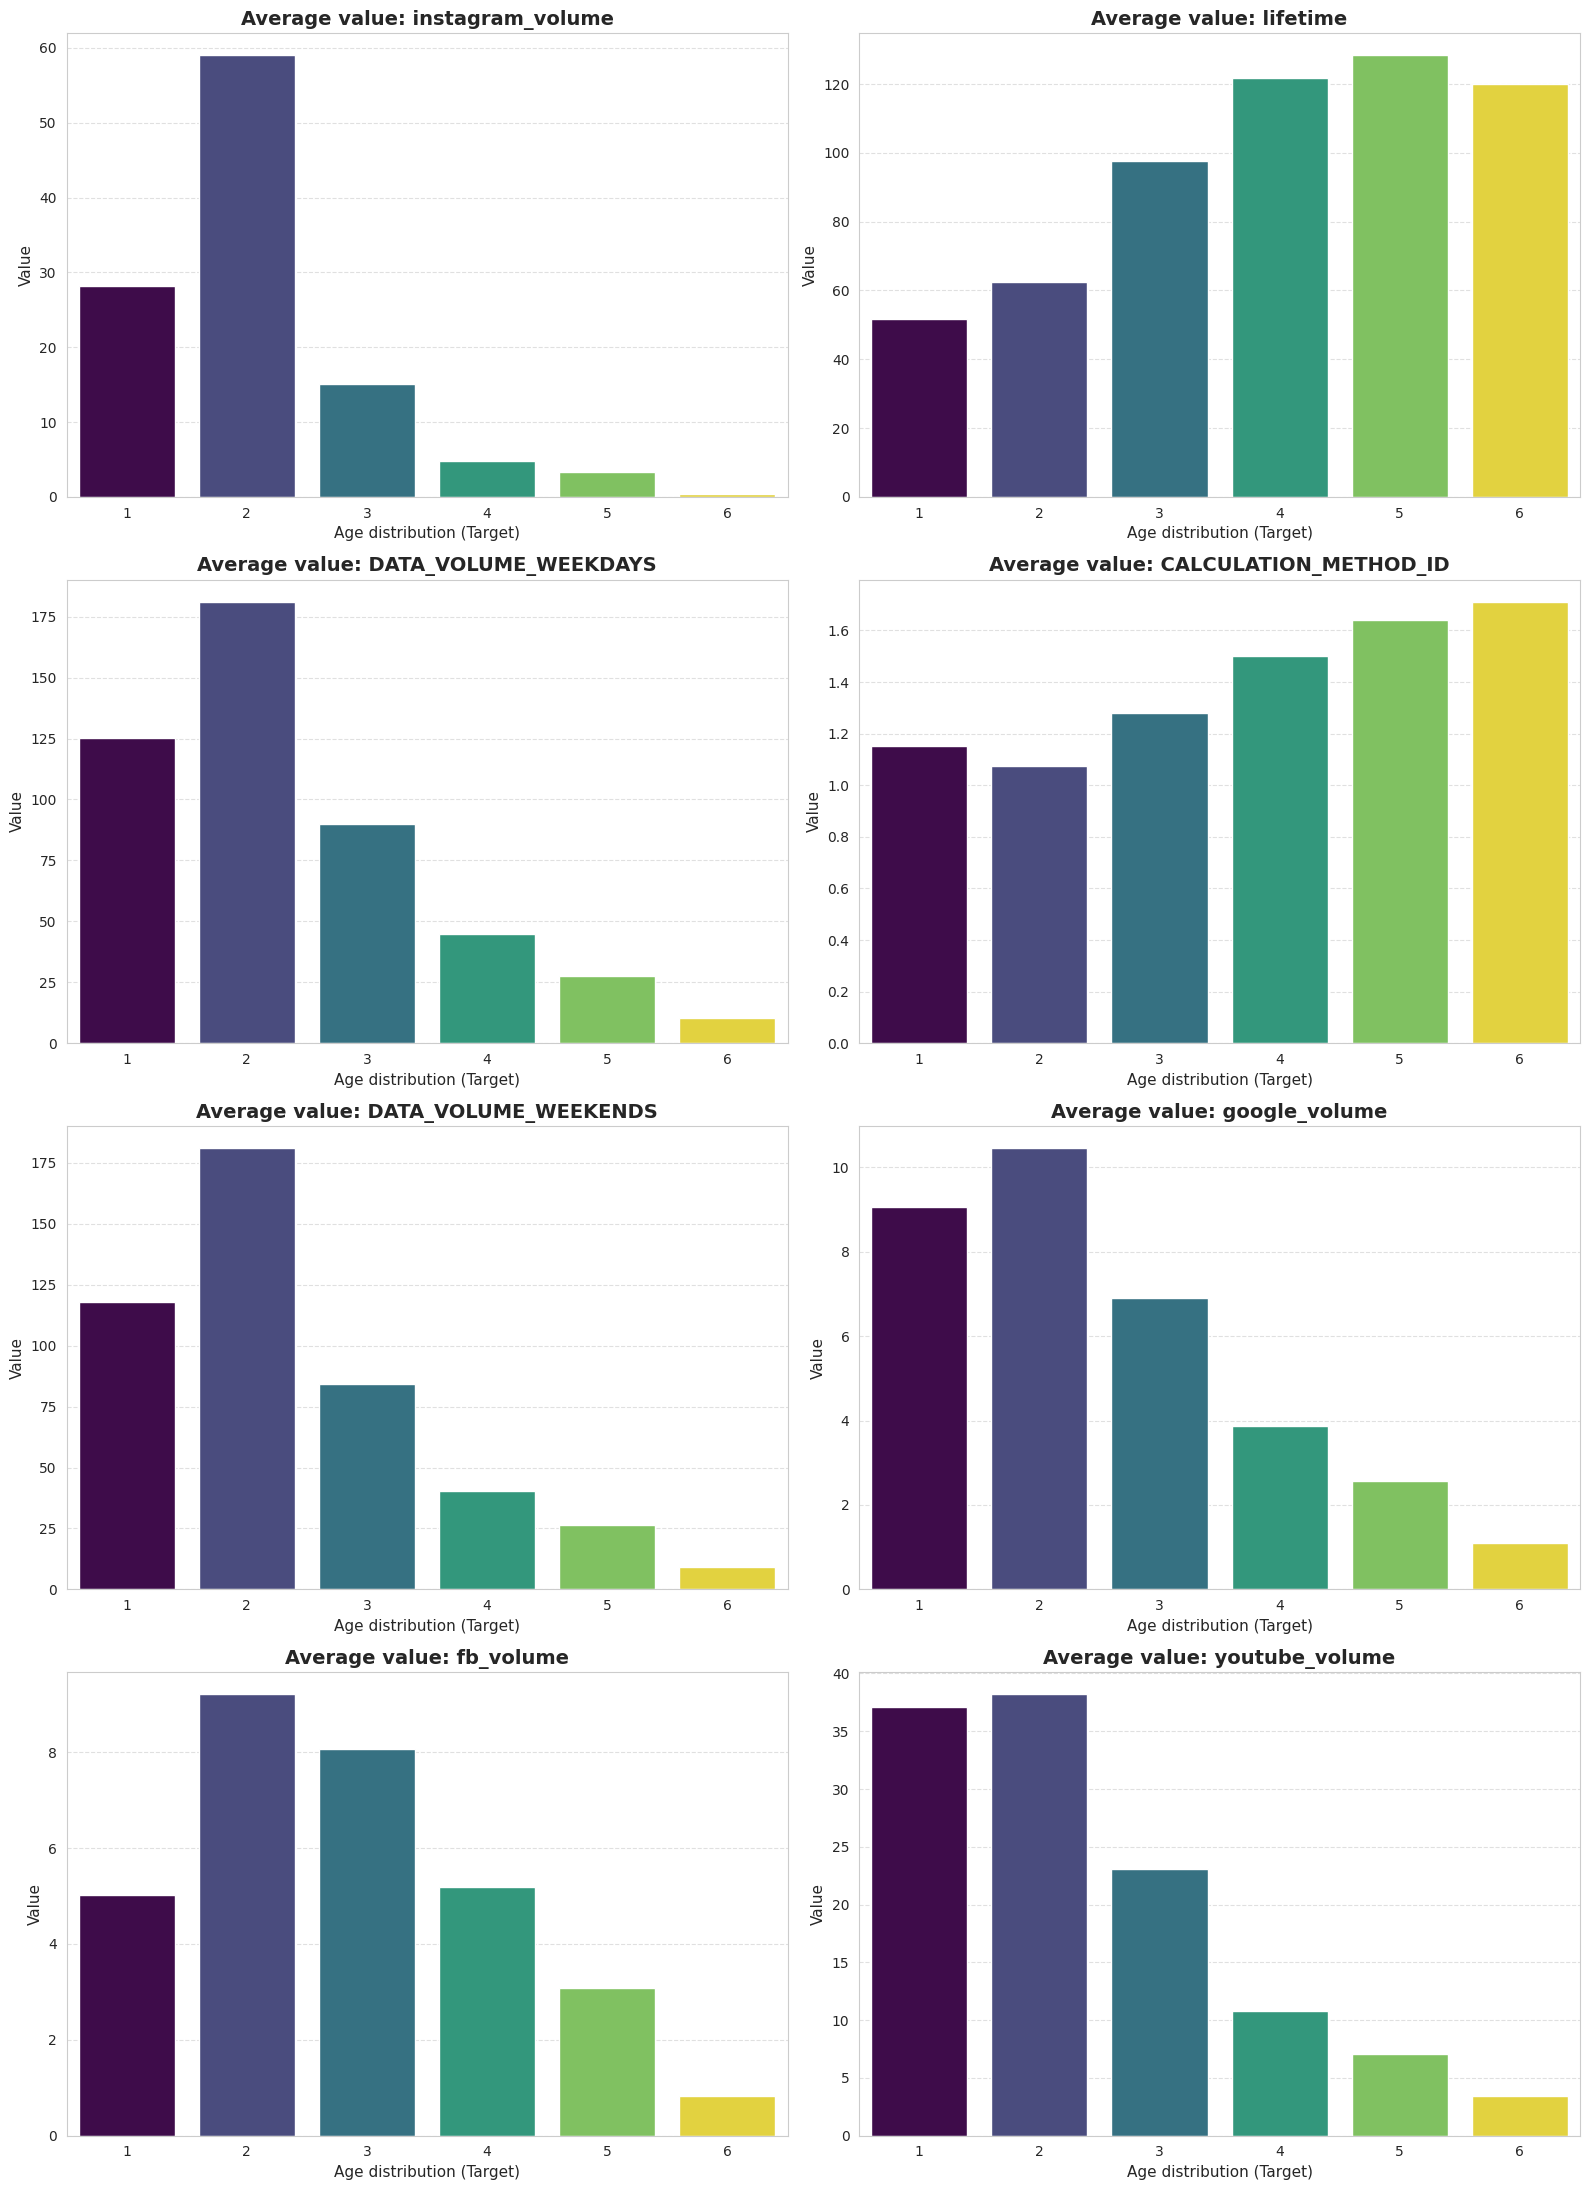

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Список ознак-лідерів
top_features = [
    'instagram_volume', 'lifetime', 'DATA_VOLUME_WEEKDAYS', 
    'CALCULATION_METHOD_ID', 'DATA_VOLUME_WEEKENDS', 
    'google_volume', 'fb_volume', 'youtube_volume'
]

# 2. Розрахунок групової статистики
grouped_stats = df_sub.groupby('target')[top_features].agg(['mean', 'median'])
grouped_stats_styled = grouped_stats.T

print("Групова статистика:")
display(grouped_stats_styled)

# 3. Візуалізація середніх значень
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.barplot(
        x=grouped_stats.index, 
        y=grouped_stats[col]['mean'], 
        ax=axes[i], 
        hue=grouped_stats.index,
        palette='viridis',
        legend=False
    )
    axes[i].set_title(f'Average value: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Age distribution (Target)', fontsize=11)
    axes[i].set_ylabel('Value', fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

        2. Feature Engineering
    
    Encoding категоріальних змінних
    
На цьому етапі проводиться підготовка текстових даних до формату, який сприймається алгоритмами машинного навчання. Оскільки застосування базових методів (як-от One-Hot Encoding) до ознак із високою кардинальністю може спричинити «прокляття розмірності» (наприклад, створення тисяч нових колонок для моделей телефонів), необхідно детально проаналізувати кожну змінну перед її перетворенням.

In [56]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Збір статистики по ознаках (Кардинальність та Зразки)

# Відбір категоріальних ознак (ті, що не є числовими)
categorical_features = df_sub.select_dtypes(exclude=[np.number]).columns.tolist()

# Видалення цільової змінної зі списку
target = 'target'
if target in categorical_features:
    categorical_features.remove(target)

print(f"Знайдено категоріальних ознак: {len(categorical_features)}\n")
print("=" * 100)

# Аналіз кожної ознаки
for col in categorical_features:
    # Отримання перших 5 унікальних значень (без урахування пропусків)
    unique_vals = df_sub[col].dropna().unique()[:5]
    total_unique = df_sub[col].nunique()
    
    print(f"Ознака: {col}")
    print(f"Перші 5 унікальних значень: {unique_vals}")
    print(f"Кількість унікальних категорій загалом: {total_unique}")
    print("-" * 100)

# Оцінка Сили Зв'язку (V Крамера)

def calculate_cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    denominator = min((k_corr-1), (r_corr-1))
    if denominator <= 0:
        return 0.0
    return np.sqrt(phi2_corr / denominator)

results_list = []

for col in categorical_features:
    total_unique = df_sub[col].nunique()
    
    if total_unique <= 1:
        continue
        
    cramers_v_val = calculate_cramers_v(df_sub[col], df_sub[target])
        
    results_list.append({
        'Feature': col,
        'Cardinality': total_unique,
        'Cramers_V': cramers_v_val
    })

# Формування підсумкового DataFrame
results_df = pd.DataFrame(results_list)

# Вивід таблиці, відсортованої за V Крамера
print("\nСписок ознак, відсортований за силою зв'язку (Cramer's V):")
display(results_df.sort_values(by='Cramers_V', ascending=False)[['Feature', 'Cramers_V', 'Cardinality']].style.hide(axis="index"))

Знайдено категоріальних ознак: 13

Ознака: Oblast_post_HOME
Перші 5 унікальних значень: ['Херсонська' 'Одеська' 'Донецька' 'Запорізька' 'Київ']
Кількість унікальних категорій загалом: 29
----------------------------------------------------------------------------------------------------
Ознака: Raion_post_HOME
Перші 5 унікальних значень: ['Каховський' 'Одеса' 'Донецьк' 'Запоріжжя' 'Київ']
Кількість унікальних категорій загалом: 548
----------------------------------------------------------------------------------------------------
Ознака: City_post_HOME
Перші 5 унікальних значень: ['Каховка' 'Одеса' 'Донецьк' 'Запоріжжя' 'Київ']
Кількість унікальних категорій загалом: 2861
----------------------------------------------------------------------------------------------------
Ознака: Oblast_post_WORK
Перші 5 унікальних значень: ['Херсонська' 'Одеська' 'Донецька' 'Запорізька' 'Київ']
Кількість унікальних категорій загалом: 29
-----------------------------------------------------------------

Feature,Cramers_V,Cardinality
device_model,0.180834,3799
device_type_rus,0.175352,4
software_os_vendor,0.146974,18
software_os_name,0.146958,31
device_brand,0.144222,315
SCORING,0.134134,6
software_os_version,0.132545,70
City_post_HOME,0.091594,2861
City_post_WORK,0.090171,2807
Raion_post_WORK,0.077960,546


На основі наведеної статистики прийнято рішення залишити та закодувати такі ознаки як device_type_rus, device_model, software_os_name, software_os_vendor, device_brand, SCORING, software_os_version. Інші категоріальні ознаки мають високу кардинальність, або занад-то низьку силу зв'язку.

    Кодування категоріальних ознак:

На основі відібраного переліку значущих параметрів проводиться трансформація текстових даних у числовий формат. Для запобігання надмірному збільшенню розмірності датасету та раціонального використання пам'яті використовується комбінований підхід:

1. One-Hot Encoding: Застосовується до ознак device_type_rus та SCORING. Оскільки ці змінні мають низьку кардинальність, створення кількох додаткових бінарних колонок є цілком безпечним і не перевантажить модель.

2. Frequency Encoding: Застосовується до висококардинальних ознак: device_model, software_os_name, software_os_vendor, device_brand та software_os_version. Кожна категорія замінюється на частоту її появи у датасеті. Це дозволяє зберегти інформацію про популярність певних операційних систем чи моделей пристроїв без створення тисяч нових розріджених стовпців.

Усі інші нечислові ознаки (наприклад, географічні дані), що не увійшли до фінального відібраного списку, автоматично видаляються для оптимізації роботи майбутніх алгоритмів.

In [57]:
import pandas as pd
import numpy as np

# Збереження розмірності до початку трансформацій
initial_shape = df_sub.shape
print(f"Кількість ознак до кодування: {initial_shape[1]} (Загальна розмірність: {initial_shape})\n")

# 1. Списки ознак за обраним типом кодування
ohe_cols = ['device_type_rus', 'SCORING']
freq_cols = ['device_model', 'software_os_name', 'software_os_vendor', 'device_brand', 'software_os_version']

# 2. Очищення датасету від незначущих категоріальних ознак
all_categorical = df_sub.select_dtypes(exclude=[np.number]).columns.tolist()

if 'target' in all_categorical:
    all_categorical.remove('target')

cols_to_drop = [col for col in all_categorical if col not in ohe_cols + freq_cols]

if len(cols_to_drop) > 0:
    df_sub = df_sub.drop(columns=cols_to_drop)
    print(f"Видалено незначущі категоріальні ознаки: {cols_to_drop}\n")

# 3. Застосування Frequency Encoding
# Кожне текстове значення замінюється на частку (відсоток) його появи
for col in freq_cols:
    if col in df_sub.columns:
        freq_encoding = df_sub[col].value_counts(normalize=True)
        df_sub[col] = df_sub[col].map(freq_encoding).fillna(0)
        
# 4. Застосування One-Hot Encoding
df_sub = pd.get_dummies(df_sub, columns=ohe_cols, drop_first=True)

# Оптимізація типів даних для нових бінарних колонок
for col in df_sub.columns:
    if df_sub[col].dtype == bool:
        df_sub[col] = df_sub[col].astype(int)

# Виведення результатів
final_shape = df_sub.shape
print("-" * 50)
print(f"Кількість ознак ПІСЛЯ кодування: {final_shape[1]}")
print(f"Фінальна розмірність датасету df_sub: {final_shape}")
print("Усі текстові ознаки успішно перетворено на числові.")

Кількість ознак до кодування: 90 (Загальна розмірність: (105000, 90))

Видалено незначущі категоріальні ознаки: ['Oblast_post_HOME', 'Raion_post_HOME', 'City_post_HOME', 'Oblast_post_WORK', 'Raion_post_WORK', 'City_post_WORK']

--------------------------------------------------
Кількість ознак ПІСЛЯ кодування: 90
Фінальна розмірність датасету df_sub: (105000, 90)
Усі текстові ознаки успішно перетворено на числові.


    Scaling / normalization
    
На цьому етапі проводиться приведення всіх числових ознак до єдиного масштабу для забезпечення стабільної роботи алгоритмів машинного навчання. Оскільки зібрані параметри мають абсолютно різні діапазони значень (наприклад, тисячі мегабайтів трафіку порівняно з кількома місяцями стажу), відсутність нормалізації призведе до того, що модель помилково надаватиме перевагу більшим числам, ігноруючи вплив математично менших показників.

In [62]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Відокремлення цільової змінної від ознак
target_col = 'target'
X = df_sub.drop(columns=[target_col])
y = df_sub[target_col]

# 2. Ініціалізація та навчання скейлера
scaler = StandardScaler()

# 3. Трансформація даних
X_scaled_array = scaler.fit_transform(X)

# 4. Повернення даних у формат DataFrame зі збереженням назв колонок
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns, index=X.index)

# 5. Об'єднання масштабованих ознак із цільовою змінною
df_final = pd.concat([X_scaled, y], axis=1)

# 6. Збереження результату для Sprint 3
output_path = "../data/final_scaled_dataset.csv"
df_final.to_csv(output_path, index=False)

print(f"Розмірність фінального датасету: {df_final.shape}")
print(f"Файл успішно збережено за шляхом: {output_path}")
print("-" * 50)
print("Демонстрація перших 5 рядків:")
display(df_final.head())

Розмірність фінального датасету: (105000, 90)
Файл успішно збережено за шляхом: ../data/final_scaled_dataset.csv
--------------------------------------------------
Демонстрація перших 5 рядків:


,CALCULATION_METHOD_ID,calls_count_in_weekdays,calls_duration_in_weekdays,calls_count_out_weekdays,calls_duration_out_weekdays,calls_count_in_weekends,calls_duration_in_weekends,calls_count_out_weekends,calls_duration_out_weekends,DATA_VOLUME_WEEKDAYS,...,telegram_count,device_type_rus_phone,device_type_rus_smartphone,device_type_rus_tablet,SCORING_HIGH,SCORING_HIGH_MEDIUM,SCORING_LOW,SCORING_MEDIUM,SCORING_VERY LOW,target
0,1.002288,-0.144723,-0.239254,-0.188442,-0.375410,-0.143076,-0.496064,-0.219858,-0.417501,-0.348097,...,-0.036041,-0.457373,0.588084,-0.00756,-0.367641,-0.58697,1.758219,-0.557227,-0.408661,4
1,1.002288,-0.379095,-0.660567,-0.291169,-0.581594,-0.069039,-0.077607,-0.232971,-0.397833,-0.348097,...,-0.036041,-0.457373,0.588084,-0.00756,-0.367641,-0.58697,-0.568757,1.794602,-0.408661,6
2,-0.997717,-0.505294,-0.791415,-0.475882,-0.737526,-0.337722,-0.497295,-0.295513,-0.305584,-0.345392,...,-0.036041,-0.457373,0.588084,-0.00756,-0.367641,-0.58697,1.758219,-0.557227,-0.408661,5
3,1.002288,0.237482,0.466104,0.164191,0.024411,0.155461,0.443157,-0.169421,-0.340811,-0.348097,...,-0.036041,2.186400,-1.700436,-0.00756,-0.367641,-0.58697,1.758219,-0.557227,-0.408661,4
4,1.002288,-0.254096,-0.047381,-0.148931,0.020531,-0.128747,-0.518037,-0.018111,0.278732,-0.036122,...,-0.036041,-0.457373,0.588084,-0.00756,-0.367641,-0.58697,1.758219,-0.557227,-0.408661,5


    3. Baseline Models


Підготовка вибірок та навчання моделей:

На цьому етапі проводиться навчання основних алгоритмів для встановлення початкового рівня якості прогнозування вікових сегментів. Використання широкого спектра моделей — від класичних лінійних методів до потужних ансамблів — дозволяє оцінити складність завдання та визначити найбільш ефективну архітектуру для роботи з даними абонентів. Це створює об’єктивну базу (baseline), від якої буде вимірюватися подальший прогрес під час оптимізації моделі. 

Стратифікований поділ вибірки гарантує збереження пропорцій між шістьма віковими категоріями як у навчальній, так і в перевірочній частинах. Оцінка проводиться за набором ключових метрик, включаючи Accuracy та F1-Score, що важливо для збалансованого аналізу точності на 105 000 записах датасету. Такий підхід дозволяє виявити найбільш стабільні моделі, які найкраще виокремлюють патерни споживання трафіку та поведінкові ознаки.

In [59]:
!pip install --upgrade pip

In [60]:
!pip install xgboost==2.0.3
!pip install xgboost lightgbm

In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 1. Train / Validation split зі стратифікацією
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Ініціалізація всіх моделей
models = {
    "kNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "HistGradientBoosting (Sklearn Fast)": HistGradientBoostingClassifier(learning_rate=0.1, max_iter=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='mlogloss', n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbose=-1, n_jobs=-1)
}

# 3. Навчання та збір метрик
results = []

for name, model in models.items():
    print(f"Навчання моделі: {name}...")
    
    # Для XGBoost мітки класів обов'язково мають починатися з 0
    if name == "XGBoost":
        y_train_xgb = y_train - y_train.min()
        y_val_xgb = y_val - y_val.min()
        model.fit(X_train, y_train_xgb)
        
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)
        
        # Розрахунок метрик для XGBoost на зсунутих мітках
        acc = accuracy_score(y_val_xgb, y_pred)
        prec = precision_score(y_val_xgb, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_val_xgb, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_val_xgb, y_pred, average='weighted')
        roc_auc = roc_auc_score(y_val_xgb, y_proba, multi_class='ovr')
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)
        
        # Розрахунок метрик для інших моделей
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='weighted')
        roc_auc = roc_auc_score(y_val, y_proba, multi_class='ovr')
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision (Weighted)": prec,
        "Recall (Weighted)": rec,
        "F1-Score (Weighted)": f1,
        "ROC-AUC (OvR)": roc_auc
    })

# 4. Побудова фінальної таблиці результатів (відсортована за точністю)
df_results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
print("\nПовна порівняльна таблиця всіх Baseline моделей:")
display(df_results)

Навчання моделі: kNN...
Навчання моделі: Logistic Regression...
Навчання моделі: Decision Tree...
Навчання моделі: Random Forest...
Навчання моделі: HistGradientBoosting (Sklearn Fast)...
Навчання моделі: XGBoost...
Навчання моделі: LightGBM...

Повна порівняльна таблиця всіх Baseline моделей:


,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),ROC-AUC (OvR)
0,HistGradientBoosting (Sklearn Fast),0.460190,0.463592,0.460190,0.459257,0.806612
1,LightGBM,0.459000,0.462973,0.459000,0.457997,0.807356
2,XGBoost,0.455238,0.461293,0.455238,0.453655,0.805077
3,Random Forest,0.430429,0.441222,0.430429,0.420940,0.789189
4,Decision Tree,0.420048,0.420765,0.420048,0.418150,0.767116
5,Logistic Regression,0.414810,0.417026,0.414810,0.408254,0.775224
6,kNN,0.355048,0.357496,0.355048,0.354621,0.665978


    Аналіз та порівняння результатів моделювання:

Аналіз результатів тестування базових моделей показує, що найкращу ефективність продемонстрували алгоритми градієнтного бустингу. Лідером за показником F1-Score став HistGradientBoosting (45.93%), за яким із мінімальним відривом слідують LightGBM (45.8%) та XGBoost (45.37%). Ці моделі значно перевершують класичні підходи, такі як логістична регресія (40.8%) чи kNN (35.46%), що підтверджує перевагу ансамблевих методів у роботі зі складними нелінійними даними абонентів.

Високий показник ROC-AUC (близько 0.80) для трійки лідерів свідчить про те, що моделі якісно ранжують вікові групи та мають гарну роздільну здатність. Отриманий рівень точності у 46% для задачі класифікації на 6 класів є вагомим результатом, оскільки він майже утричі перевищує точність випадкового вгадування (16.6%). Це створює надійну базу для подальшої оптимізації, де HistGradientBoosting, LightGBM та XGBoost є основними кандидатами для фінального тюнінгу гіперпараметрів.